# Day 3: Analyzing MESA Outputs

In this notebook, we'll take a quick look at the MESA outputs. 

You can run this on Google colab or download this as a Jupyter notebook and run it on your laptop locally. 

In [1]:
# this cell imports all the necessary libraries

import numpy as np

import matplotlib.pyplot as plt
import matplotlib as matplotlib

import mesa_reader as mr

MESA has two kinds of outputs:
- History file (history.data): This records some global quantities throughout the evolution of the star, e.g., total stellar mass, surface luminosity, etc., at different steps of the MESA run.
  
- Profiles (profile*.data): This is essentially a snapshot of the star, at a *single* timestep. This records the structural quantities of the star, like how the density and temperature vary throughout the star, *at that moment*. 

## history file

You can download the following history.data here {download}`first_run/history.data`.

In [8]:
# load 
myh = mr.MesaData('first_run/history.data')

Let's take a look at the contents in the history data:

In [4]:
myh.bulk_names

('model_number',
 'num_zones',
 'star_age',
 'log_dt',
 'star_mass',
 'log_xmstar',
 'log_abs_mdot',
 'mass_conv_core',
 'conv_mx1_top',
 'conv_mx1_bot',
 'conv_mx2_top',
 'conv_mx2_bot',
 'mx1_top',
 'mx1_bot',
 'mx2_top',
 'mx2_bot',
 'log_power_nuc_burn',
 'power_nuc_burn',
 'log_LH',
 'log_LHe',
 'log_LZ',
 'log_Lnuc',
 'Lnuc',
 'pp',
 'cno',
 'tri_alpha',
 'epsnuc_M_1',
 'epsnuc_M_2',
 'epsnuc_M_3',
 'epsnuc_M_4',
 'epsnuc_M_5',
 'epsnuc_M_6',
 'epsnuc_M_7',
 'epsnuc_M_8',
 'he_core_mass',
 'co_core_mass',
 'one_core_mass',
 'fe_core_mass',
 'neutron_rich_core_mass',
 'log_Teff',
 'log_L',
 'log_R',
 'log_g',
 'v_div_csound_surf',
 'log_cntr_P',
 'log_cntr_Rho',
 'log_cntr_T',
 'center_mu',
 'center_ye',
 'center_abar',
 'center_h1',
 'center_he4',
 'center_c12',
 'center_o16',
 'surface_c12',
 'surface_o16',
 'total_mass_h1',
 'total_mass_he4',
 'num_retries',
 'num_iters')

These quantities can be accessed like this:

In [9]:
myh.model_number

array([  1,   5,  10,  15,  20,  25,  30,  35,  40,  45,  50,  55,  60,
        65,  70,  75,  80,  85,  90,  95, 100, 105, 110, 115, 120, 125,
       130, 135, 140, 145, 150, 155, 160, 165, 170, 175, 180, 185, 190,
       195, 200, 205, 210, 215, 220, 225, 230, 235, 240, 245, 250, 255,
       260, 265, 270, 275, 280, 285, 290, 295, 300, 305, 310, 315])

and you can see that they are arrays. 

The corresponding age of the star is (in years):

In [10]:
myh.star_age

array([1.00000000e-05, 7.44160000e-05, 2.59586821e-04, 7.20351079e-04,
       1.86688000e-03, 4.71981083e-03, 1.18188157e-02, 2.94834115e-02,
       7.34385784e-02, 1.82813099e-01, 4.54971908e-01, 1.13219011e+00,
       2.81732572e+00, 7.01048235e+00, 1.74443978e+01, 4.34073185e+01,
       1.08011373e+02, 2.68766934e+02, 6.68778212e+02, 1.66413428e+03,
       4.14089868e+03, 1.03038811e+04, 2.56393534e+04, 6.37989160e+04,
       1.58752119e+05, 3.95026072e+05, 9.82951275e+05, 2.44589732e+06,
       5.34970356e+06, 9.31371345e+06, 1.42259465e+07, 1.98681399e+07,
       2.59711902e+07, 3.66888203e+07, 6.33577135e+07, 1.29718454e+08,
       2.94845212e+08, 7.05733426e+08, 1.43671293e+09, 2.10459327e+09,
       2.75571209e+09, 3.39112911e+09, 4.00862577e+09, 4.60558322e+09,
       5.17959950e+09, 5.72890112e+09, 6.25170366e+09, 6.74415310e+09,
       7.20563378e+09, 7.61186434e+09, 7.88685091e+09, 8.09571104e+09,
       8.27605691e+09, 8.43985407e+09, 8.59150596e+09, 8.73280874e+09,
      

### HR diagram

Let's plot how the star evolves on the HR diagram.

Text(0, 0.5, '$\\log_{10}(L/L_{\\odot})$')

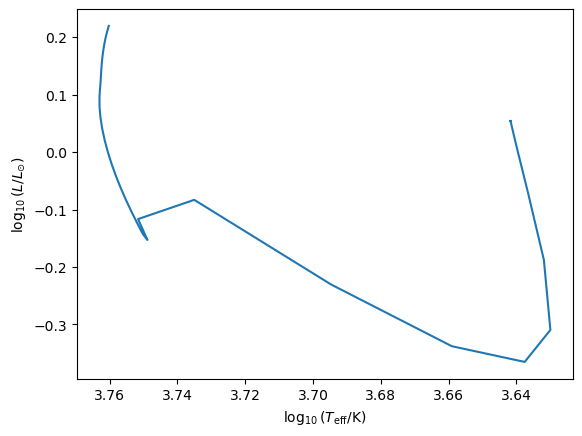

In [12]:
plt.plot(myh.log_Teff,myh.log_L)

# for historical reasons, the HR diagram plots 
# higher temperatures towards the left
plt.gca().invert_xaxis()

# axis labels
plt.xlabel('$\log_{10}(T_{\\rm eff}/\\rm{K})$')
plt.ylabel('$\log_{10}(L/L_{\odot})$')

### Luminosity evolution

We can also look at how the surface luminosity of the star (power output that the star radiates) compares to its nuclear burning luminosity (power output from nuclear burning), at different ages.

Text(0, 0.5, '$\\log_{10}(L/L_{\\odot})$')

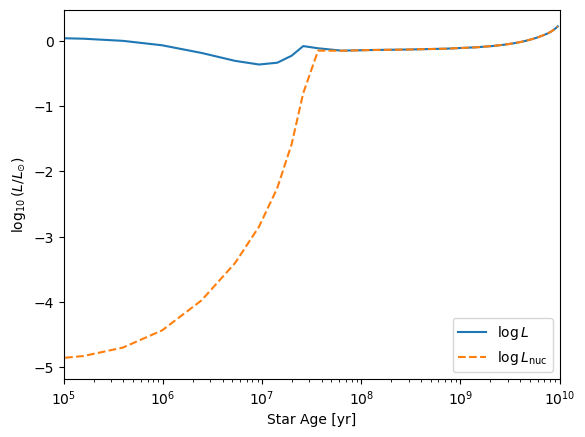

In [19]:
plt.plot(myh.star_age,myh.log_L,label='$\log L$')

plt.plot(myh.star_age,myh.log_Lnuc,label='$\log L_{\\rm nuc}$',ls='--')

# add legend
plt.legend()

# change x axis limits and change to log scale
plt.semilogx()
plt.xlim(1e5,1e10)

# add axis labels
plt.xlabel('Star Age [yr]')
plt.ylabel('$\log_{10}(L/L_{\odot})$')

You can see that the star starts nuclear burning after $\sim 10^{7}~$yrs, and continues nuclear burning for the next $\sim 10^{10}~$yrs. This is the main sequence lifetime of the Sun. 

During this time, the star remains in thermal equilibrium: it radiates as much energy at its surface as nuclear burning generates at its core. 